Training CNN with Randomized Noise Injection...
Epoch 05/15 | Training Loss: 0.0000
Epoch 10/15 | Training Loss: 0.0000
Epoch 15/15 | Training Loss: 0.0000

CERTIFICATION RESULTS
Predicted Robust Label : Class 1
Empirical Consensus Probability (p_A) : 99.6%
Certified L2 Robustness Radius : 1.3260


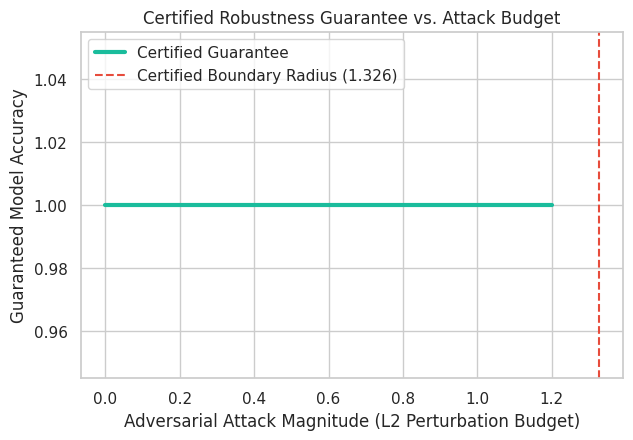

In [ ]:
# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import torch  # deep learning
import torch.nn as nn  # neural layers
import torch.optim as optim  # model trainers
from scipy.stats import norm  # math cdf calculations
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling

warnings.filterwarnings('ignore')  # hide warnings

SEED = 42  # standard seed
torch.manual_seed(SEED)  # seed pytorch
np.random.seed(SEED)  # seed numpy

# ==========================================
# Robust Neural Network Model
# ==========================================

class RobustCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 1-channel input (grayscale), 8-channel hidden space
        self.conv = nn.Conv2d(1, 8, kernel_size=3, padding=1)  # conv layer
        self.fc = nn.Linear(8 * 28 * 28, 2)  # output classifier

    def forward(self, x):
        x = torch.relu(self.conv(x))  # activate conv
        x = x.view(x.size(0), -1)  # flatten tensor
        return self.fc(x)  # return logits

# ==========================================
# Data Generation & Training
# ==========================================

# Create 10 synthetic grayscale 28x28 images
X_train = torch.randn(10, 1, 28, 28)  # fake images
y_train = torch.randint(0, 2, (10,))  # binary labels (0 or 1)

# Initialize network and optimizer
model = RobustCNN()  # load network
optimizer = optim.Adam(model.parameters(), lr=0.01)  # load optimizer
criterion = nn.CrossEntropyLoss()  # loss objective

# Hyperparameters for defense smoothing
noise_level_sigma = 0.5  # standard deviation of added noise

print("Training CNN with Randomized Noise Injection...")  # status log
for epoch in range(15):  # train epochs
    # Generate Gaussian perturbation noise
    noise = torch.randn_like(X_train) * noise_level_sigma  # noise scale

    # Forward pass on NOISY images (Smooth Training)
    outputs = model(X_train + noise)  # model prediction
    loss = criterion(outputs, y_train)  # calculate loss

    optimizer.zero_grad()  # clean gradients
    loss.backward()  # backpropagation
    optimizer.step()  # update weights

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/15 | Training Loss: {loss.item():.4f}")

# ==========================================
# Certified Robustness Solver
# ==========================================

def certify_robustness(model, x, sigma, n_samples=500):
    model.eval()  # freeze trainable weights

    with torch.no_grad():  # freeze gradients
        # Repeat input sample x to run parallel Monte Carlo passes
        x_repeated = x.repeat(n_samples, 1, 1, 1)  # stack input copies
        noise = torch.randn_like(x_repeated) * sigma  # generate noise matrix

        logits = model(x_repeated + noise)  # batch forward pass
        preds = torch.argmax(logits, dim=1).numpy()  # get predicted classes

    # Find majority class counts
    counts = np.bincount(preds, minlength=2)  # bin votes
    majority_class = np.argmax(counts)  # select top class
    class_votes = counts[majority_class]  # select top vote count

    # Calculate probability lower bound p_A
    p_A = class_votes / n_samples  # confidence fraction

    # Calculate Certified L2 Radius using Inverse Normal Cumulative Distribution
    if p_A > 0.5:  # must have strict consensus majority
        certified_radius = sigma * norm.ppf(p_A)  # compute robust boundary
    else:
        certified_radius = 0.0  # uncertified sample

    return majority_class, p_A, certified_radius  # return robustness statistics

# ==========================================
# Testing Certified Security
# ==========================================

# Select a single test image
x_test = torch.randn(1, 1, 28, 28)  # mock test sample

# Certify robustness
pred_class, confidence, radius = certify_robustness(model, x_test, noise_level_sigma)

print("\n=====================================")
print("CERTIFICATION RESULTS")
print("=====================================")
print(f"Predicted Robust Label : Class {pred_class}")
print(f"Empirical Consensus Probability (p_A) : {confidence * 100:.1f}%")
print(f"Certified L2 Robustness Radius : {radius:.4f}")
print("=====================================")

# ==========================================
# Visualizing Safety Boundary Graph
# ==========================================

# Show how Certified Accuracy decays as an attacker's perturbation budget increases
perturbation_budgets = np.linspace(0.0, 1.2, 100)  # attack magnitudes list
certified_accuracy = []  # holding list

for budget in perturbation_budgets:
    # If budget is smaller than our certified radius, security is 100% guaranteed!
    accuracy = 1.0 if budget < radius else 0.0  # safe threshold switch
    certified_accuracy.append(accuracy)  # log accuracy status

sns.set_theme(style="whitegrid")  # set theme
plt.figure(figsize=(7, 4.5))  # canvas layout
plt.plot(perturbation_budgets, certified_accuracy, color='#1abc9c', lw=3, label='Certified Guarantee')  # draw line
plt.axvline(x=radius, color='#e74c3c', linestyle='--', label=f'Certified Boundary Radius ({radius:.3f})')  # boundary limit marker
plt.xlabel('Adversarial Attack Magnitude (L2 Perturbation Budget)')  # x label
plt.ylabel('Guaranteed Model Accuracy')  # y label
plt.title('Certified Robustness Guarantee vs. Attack Budget')  # plot title
plt.legend()  # build legend
plt.show()  # display plot